# EDA On the tips Dataset
## Goal
The goal is to understand the data 

1. Understand the dataset
2. Check the data quality
3. Univaraite Analysis
4. investigate realtionships between variables(bivariate analysis)
5. Find useful Patterns
6. Explain those Patterns
7. Eda Summary

## 1. imports And Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = sns.load_dataset('tips')
print(f"Rows: {df.shape[0]}")
print(f"columns: {df.shape[1]}")

Rows: 244
columns: 7


In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 2. Understand the datset
- check info about the data
- check data types 
- what is our target features

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [6]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [7]:
df.describe(include="category")

,sex,smoker,day,time
count,244,244,244,244
unique,2,2,4,2
top,Male,No,Sat,Dinner
freq,157,151,87,176


**Observations:**
- there are 244 rows and 7 columns.
- dataset contains numerical and categorical features
- the numerical features are total_bill , tip and size
- the categorical features are sex, smoker, day, time.

## 3. Data Quality

### 3.1 Missing values

In [9]:
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

There are no missing values.

### 3.2 Duplicates rows

In [10]:
df.duplicated().sum()

np.int64(1)

In [14]:
df[df.duplicated(keep=False)]

,total_bill,tip,sex,smoker,day,time,size
198,13.0,2.0,Female,Yes,Thur,Lunch,2
202,13.0,2.0,Female,Yes,Thur,Lunch,2


so yes there is 1 duplicate rows and we need to drop this rows.

In [16]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

### 3.3 Data quality check
- unique values in categorical columns
- Any suspicious Values
- min and max values
- any inconsistent categories/spelling

In [21]:
categorical_cols = df.select_dtypes(include="category").columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))
    print(f"Unique :{df[col].unique()}")
    print("-"*50)


sex:
sex
Male      157
Female     86
Name: count, dtype: int64
Unique :['Female', 'Male']
Categories (2, str): ['Male', 'Female']
--------------------------------------------------

smoker:
smoker
No     151
Yes     92
Name: count, dtype: int64
Unique :['No', 'Yes']
Categories (2, str): ['Yes', 'No']
--------------------------------------------------

day:
day
Sat     87
Sun     76
Thur    61
Fri     19
Name: count, dtype: int64
Unique :['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, str): ['Thur', 'Fri', 'Sat', 'Sun']
--------------------------------------------------

time:
time
Dinner    176
Lunch      67
Name: count, dtype: int64
Unique :['Dinner', 'Lunch']
Categories (2, str): ['Lunch', 'Dinner']
--------------------------------------------------


In [28]:
numerical_cols = df.select_dtypes(include='number')
for col in numerical_cols:
    print(f"{col}: min = {df[col].min()} , max ={df[col].max()}")


total_bill: min = 3.07 , max =50.81
tip: min = 1.0 , max =10.0
size: min = 1 , max =6


no inconsistent data are visibles

## 4. Univaraite Analysis

### 4.1 Numeircal distrubtion
Numerical columns in this dataset:
- `total_bill`
- `tip`
- `size`

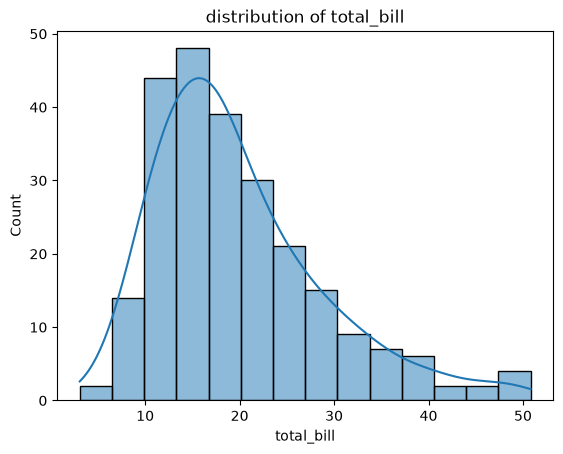

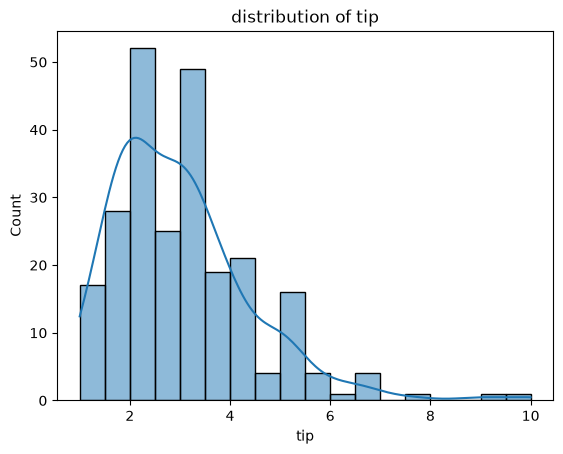

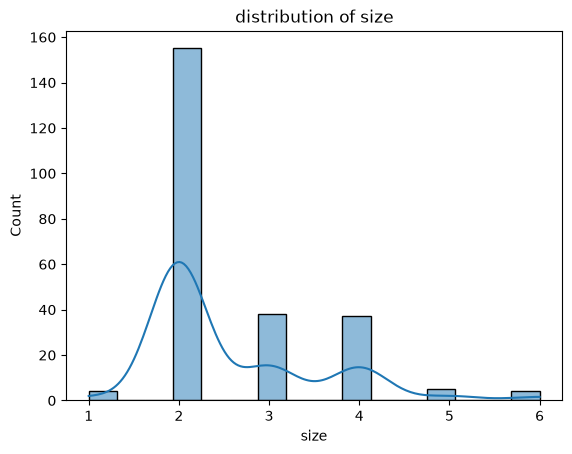

In [29]:
for col in numerical_cols:
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f"distribution of {col}")
    plt.show()

**Observation:**
- `total_bill`: Most observations are concentrated between 10 and 20, and the distribution is right-skewed, meaning there are some higher bill values stretching the distribution toward the right.
- `tip`: Most observations are concentrated between 2 and 4, and the distribution is also right-skewed, with some larger tip values extending toward the right.
- `size`: The size distribution is discrete and multimodal, with most observations concentrated at size 2. Sizes 3 and 4 are also relatively common, while sizes 1, 5, and 6 occur less frequently

In [30]:
for col in numerical_cols:
    print(f"{col}: {df[col].skew()}")

total_bill: 1.1273625781584489
tip: 1.4598015326171103
size: 1.4416130874376414


i expected that they are all positively high skewed.

### 4.2 Numeical outliers

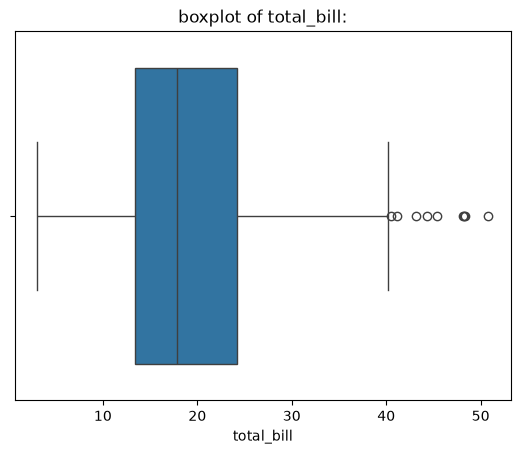

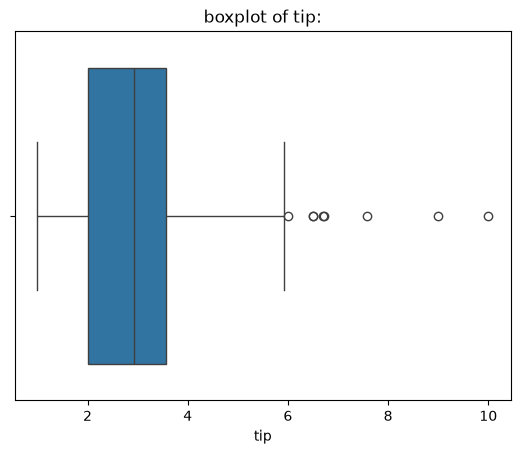

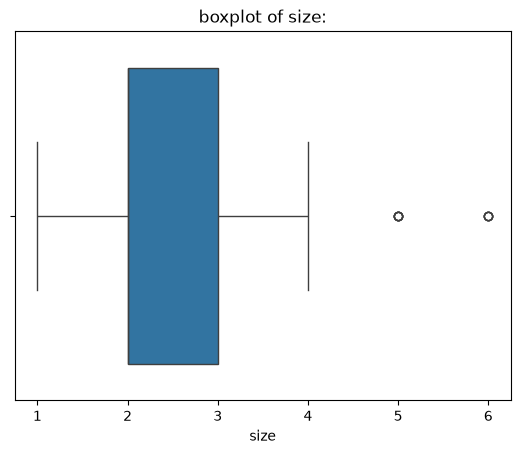

In [31]:
for col in numerical_cols:
    sns.boxplot(x=col, data=df )
    plt.title(f"boxplot of {col}:")
    plt.show()

**observations:**
- in all numerical features there are some potentaial outliers are visible . we need to investiagte. either they are actual outliers or its showing real world

### 4.3 categorical Variables

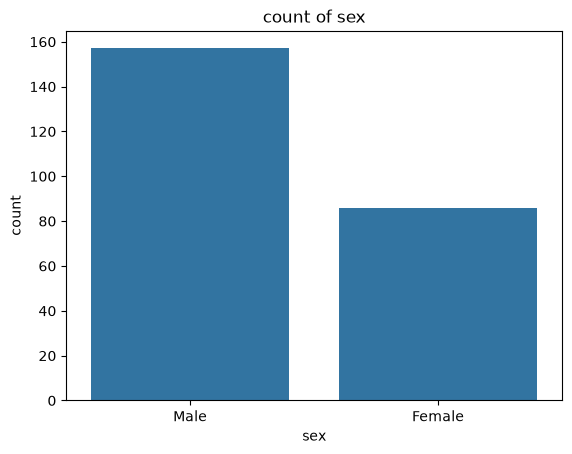

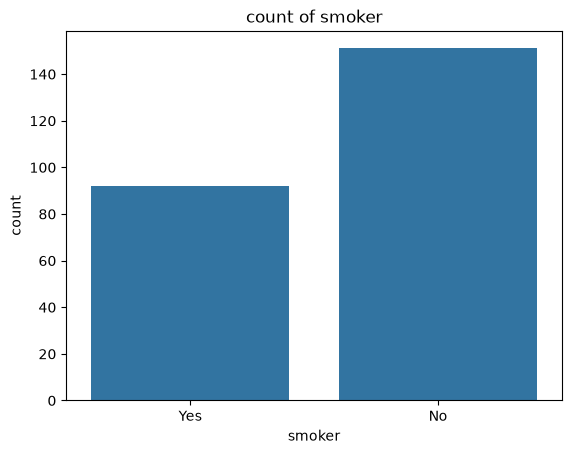

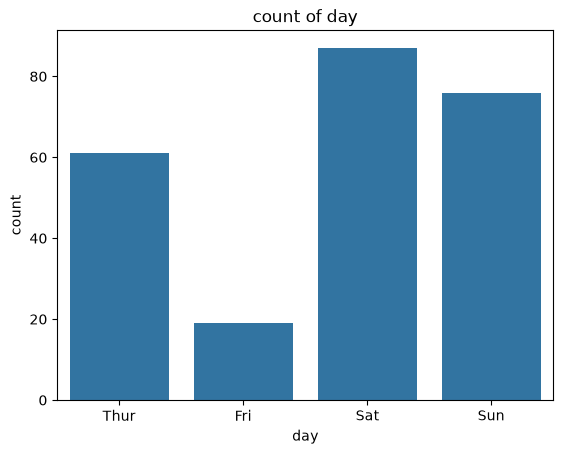

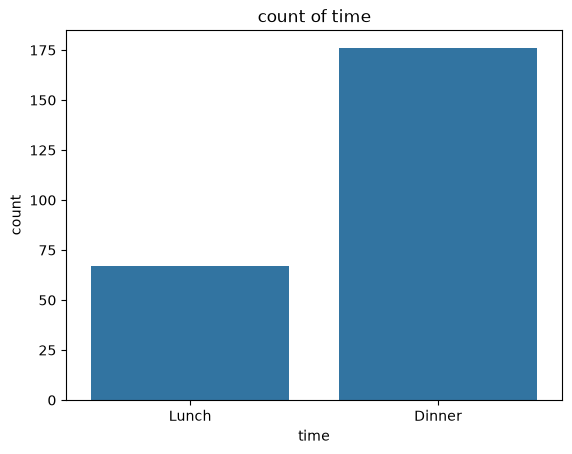

In [32]:
for col in categorical_cols:
    sns.countplot(x=col, data=df)
    plt.title(f"count of {col}")
    plt.show()

In [34]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts(normalize=True).mul(100).round(1))
    print("-"*50)


sex
sex
Male      64.6
Female    35.4
Name: proportion, dtype: float64
--------------------------------------------------

smoker
smoker
No     62.1
Yes    37.9
Name: proportion, dtype: float64
--------------------------------------------------

day
day
Sat     35.8
Sun     31.3
Thur    25.1
Fri      7.8
Name: proportion, dtype: float64
--------------------------------------------------

time
time
Dinner    72.4
Lunch     27.6
Name: proportion, dtype: float64
--------------------------------------------------
